In [2]:
from typing import Dict, Any

from model_ranking.supervised_training import get_supervised_loader
from model_ranking.dataclass import (
    SelfTrainingDataConfig,
)
from model_ranking.utils import get_roi_slice

from torch_em.data.segmentation_dataset import SegmentationDataset

In [2]:
data_config: Dict[str, Any] = {
    "unsupervised_train_paths": ["/scratch/talks/data/EPFL/train.h5"],
    "unsupervised_val_paths": ["/scratch/talks/data/EPFL/val.h5"],
    "patch_shape": [1, 256, 256],
    "supervised_train_paths": ["/scratch/talks/data/EPFL/train.h5"],
    "supervised_val_paths": ["/scratch/talks/data/EPFL/val.h5"],
    "raw_key": "raw",
    "raw_key_supervised": "raw",
    "label_key": "labels",
    "batch_size": 32,
    "num_workers": 32,
    "n_samples_train": None,
    "n_samples_val": None,
    "roi_unsupervised_train": [[101, 166], [0, 480], [0, 640]],
    "roi_unsupervised_val": [[21, 41], [0, 480], [0, 640]],
    "roi_supervised_train": [[0, 100], [0, 480], [0, 640]],
    "roi_supervised_val": [[0, 20], [0, 480], [0, 640]],
}

In [3]:
data_cfg = SelfTrainingDataConfig.model_validate(data_config)

In [4]:
rois_val = [get_roi_slice(data_config["roi_unsupervised_val"])]

In [16]:
ds = SegmentationDataset(
    data_config["unsupervised_train_paths"][0],
    raw_key=data_config["raw_key"],
    label_path=data_config["unsupervised_train_paths"][0],
    label_key=data_config["label_key"],
    patch_shape=data_config["patch_shape"],
    roi=None,
)

In [17]:
print(len(ds))

774


In [19]:
32*50

1600

In [6]:
raw, label = ds[0]
print(raw.shape, label.shape)

torch.Size([1, 1, 256, 256]) torch.Size([1, 1, 256, 256])


In [7]:
from torch_em.data.sampler import MinForegroundSampler

supervised_val_loader = get_supervised_loader(
    data_config["supervised_train_paths"],
    data_config["raw_key_supervised"],
    data_config["label_key"],
    data_config["patch_shape"],
    data_config["batch_size"],
    "/g/kreshuk/talks/model_ranking/notebooks/checks",
    num_workers=data_config["num_workers"],
    n_samples=data_config["n_samples_train"],
    rois=None,
    sampler=MinForegroundSampler(0.01),
)

In [8]:
raw, label = next(iter(supervised_val_loader))

In [11]:
print(raw.shape, label.shape)

torch.Size([32, 1, 1, 256, 256]) torch.Size([32, 1, 1, 256, 256])


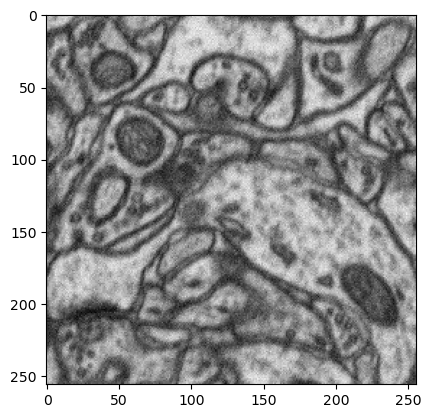

In [9]:
import matplotlib.pyplot as plt

_ = plt.imshow(raw[0].numpy().squeeze(), cmap="gray")
plt.show()

In [3]:
data_supervised_cfg: Dict[str, Any] = {
    "patch_shape": [1, 256, 256],
    "supervised_train_paths": ["/scratch/talks/data/EPFL/train.h5"],
    "supervised_val_paths": ["/scratch/talks/data/EPFL/val.h5"],
    "raw_key": "raw",
    "label_key": "labels",
    "batch_size": 2,
    "num_workers": 1,
    "n_samples_train": None,
    "n_samples_val": None,
    "roi_supervised_train": None,
    "roi_supervised_val": None,
}

In [4]:
supervised_loader = get_supervised_loader(
    data_supervised_cfg["supervised_train_paths"],
    data_supervised_cfg["raw_key"],
    data_supervised_cfg["label_key"],
    data_supervised_cfg["patch_shape"],
    data_supervised_cfg["batch_size"],
    "/g/kreshuk/talks/model_ranking/notebooks/checks",
    num_workers=data_supervised_cfg["num_workers"],
    n_samples=data_supervised_cfg["n_samples_train"],
    rois=None,
)

In [5]:
print(len(supervised_loader.dataset))

774


In [6]:
raw, label = next(iter(supervised_loader))

KeyboardInterrupt: 

In [14]:
print(raw.shape, label.shape)

torch.Size([2, 1, 1, 256, 256]) torch.Size([2, 1, 1, 256, 256])


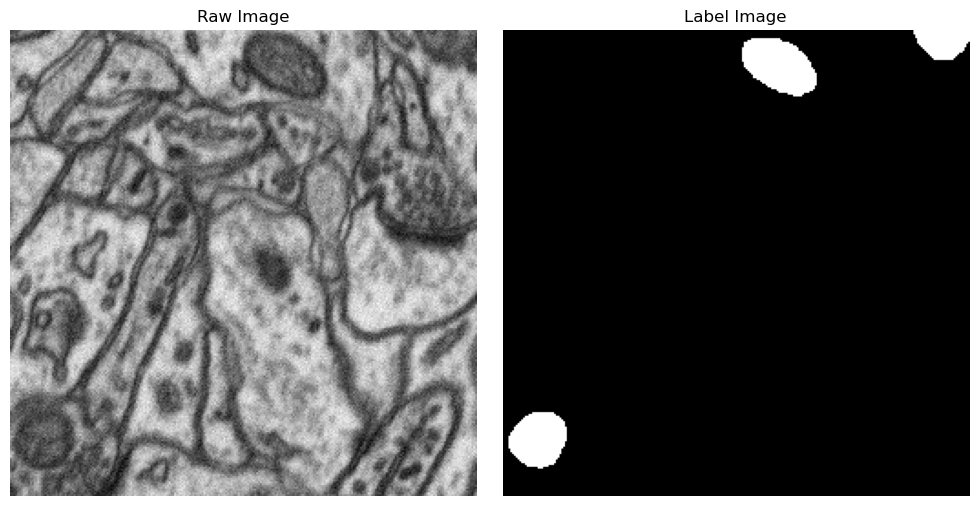

In [16]:
import matplotlib.pyplot as plt

_, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(raw[0].numpy().squeeze(), cmap="gray")
axs[0].set_title("Raw Image")
axs[1].imshow(label[0].numpy().squeeze(), cmap="gray")
axs[1].set_title("Label Image")
axs[0].axis("off")
axs[1].axis("off")
plt.tight_layout()
plt.show()